# WIP non functional

# Get Data

### Connection

postgres connection

In [195]:
import os

from config import Base
from dotenv import load_dotenv
from sqlalchemy import Engine, create_engine
from sqlalchemy.orm import Session

try:
    load_dotenv()

    db_url = os.getenv("DATABASE_URL")

    if not db_url:
        print("Erreur : DATABASE_URL est vide ou non définie.")


    if db_url.startswith("postgres://"):
        db_url = db_url.replace("postgres://", "postgresql://", 1)

    engine: Engine = create_engine(db_url)
    Base.metadata.create_all(engine)
    session: Session = Session(engine)

except Exception as e:
    print("DB error:", e)
    raise Exception(e)

if session:
    print("connection succeded")
else :
    print("connection failed")


connection succeded


### Request

SQL get user and practice 

In [196]:
from config import Practice, User
from sqlalchemy import func, select, text
from sqlalchemy.orm import aliased

P2 = aliased(Practice)
query = (
    session.query(
        Practice,
    )
)

practices = query.all()

### Format data

list data

In [197]:
from datetime import date


def calculate_age(birth_date: date) -> int:
    today = date.today()

    return (
        today.year
        - birth_date.year
        - ((today.month, today.day) < (birth_date.month, birth_date.day))
    )

header = ["user_id", "user_physical_activity_level", "user_bmi", "user_age", "user_body_fat_pct", "favorite_exercise_category", "exercice name"]

datas = []

for practice in practices:
    exercice = practice.exercise
    user : User = practice.user

    data = [
        str(user.id), user.physical_activity_level.lower(), float(user.bmi), calculate_age(user.birthdate), float(user.body_fat_pct), user.favorite_exercise_category, exercice.name
    ]
    datas.append(data)

print(datas[0])
print(len(datas))

['016b6756-e49e-402b-930e-65ffc3dc43c4', 'moderate', 17.89, 63, 30.56, 'Musculation', 'Développé Unilatéral au Kettlebell']
587536


Close db connection

In [198]:
session.close()

convert data to pandas dataframe

In [199]:
import pandas as pd

df = pd.DataFrame(datas, columns=header)

In [200]:
df.to_csv("output.csv", index=False)

### Check data

df

In [201]:
df.shape


(587536, 7)

In [202]:
df.columns


Index(['user_id', 'user_physical_activity_level', 'user_bmi', 'user_age',
       'user_body_fat_pct', 'favorite_exercise_category', 'exercice name'],
      dtype='str')

In [203]:
df.info()        # data type + missing value

<class 'pandas.DataFrame'>
RangeIndex: 587536 entries, 0 to 587535
Data columns (total 7 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       587536 non-null  str    
 1   user_physical_activity_level  587536 non-null  str    
 2   user_bmi                      587536 non-null  float64
 3   user_age                      587536 non-null  int64  
 4   user_body_fat_pct             587536 non-null  float64
 5   favorite_exercise_category    587536 non-null  str    
 6   exercice name                 587536 non-null  str    
dtypes: float64(2), int64(1), str(4)
memory usage: 31.4 MB


In [204]:
df.head()


,user_id,user_physical_activity_level,user_bmi,user_age,user_body_fat_pct,favorite_exercise_category,exercice name
0,016b6756-e49e-402b-930e-65ffc3dc43c4,moderate,17.89,63,30.56,Musculation,Développé Unilatéral au Kettlebell
1,016b6756-e49e-402b-930e-65ffc3dc43c4,moderate,17.89,63,30.56,Musculation,Curl Concentration à la Poulie
2,016b6756-e49e-402b-930e-65ffc3dc43c4,moderate,17.89,63,30.56,Musculation,Extension Hip Thrust à la Machine
3,016b6756-e49e-402b-930e-65ffc3dc43c4,moderate,17.89,63,30.56,Musculation,Fentes Arrière aux Haltères
4,016b6756-e49e-402b-930e-65ffc3dc43c4,moderate,17.89,63,30.56,Musculation,Développé Unilatéral aux Haltères


In [205]:
df.tail()

,user_id,user_physical_activity_level,user_bmi,user_age,user_body_fat_pct,favorite_exercise_category,exercice name
587531,fff8aecf-7c28-4391-9672-ebc8982af687,moderate,18.8,18,10.5,Musculation,Rowing Yates à la Barre
587532,fff8aecf-7c28-4391-9672-ebc8982af687,moderate,18.8,18,10.5,Musculation,Rowing Unilatéral à la Poulie
587533,fff8aecf-7c28-4391-9672-ebc8982af687,moderate,18.8,18,10.5,Musculation,Curl Biceps à la Barre
587534,fff8aecf-7c28-4391-9672-ebc8982af687,moderate,18.8,18,10.5,Musculation,Soulevé de terre Unilatéral à la Barre
587535,fff8aecf-7c28-4391-9672-ebc8982af687,moderate,18.8,18,10.5,Musculation,Curl Zottman à la Barre


data repartition

In [206]:
df.describe(include='all')

,user_id,user_physical_activity_level,user_bmi,user_age,user_body_fat_pct,favorite_exercise_category,exercice name
count,587536,587536,587536.000000,587536.000000,587536.000000,587536,587536
unique,9731,3,NaN,NaN,NaN,3,231
top,0726b070-852f-4aa7-9fe9-865864ed9b41,moderate,NaN,NaN,NaN,Musculation,Développé Assis aux Haltères
freq,83,395615,NaN,NaN,NaN,585827,7743
mean,NaN,NaN,23.729496,38.960600,26.397838,NaN,NaN
std,NaN,NaN,3.750207,12.818687,7.375171,NaN,NaN
min,NaN,NaN,8.700000,18.000000,0.370000,NaN,NaN
25%,NaN,NaN,21.190000,28.000000,20.910000,NaN,NaN
50%,NaN,NaN,23.900000,38.000000,26.560000,NaN,NaN
75%,NaN,NaN,26.400000,49.000000,31.880000,NaN,NaN


In [207]:
df.isnull().sum()

user_id                         0
user_physical_activity_level    0
user_bmi                        0
user_age                        0
user_body_fat_pct               0
favorite_exercise_category      0
exercice name                   0
dtype: int64

cut it too avoid bad readability of diagram

In [208]:
sample_df = df.sample(n=2000, random_state=42)

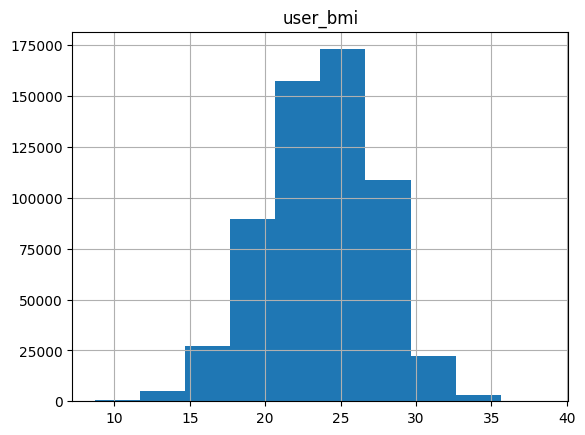

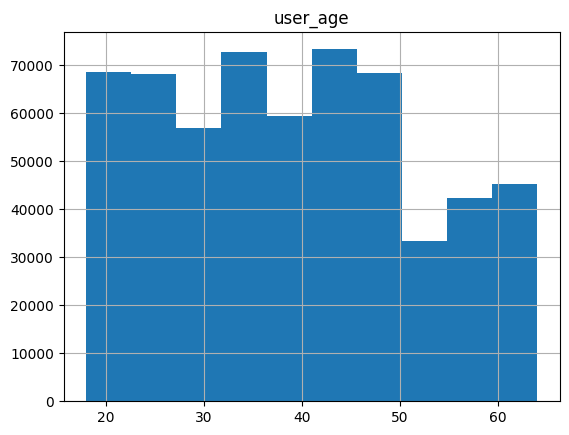

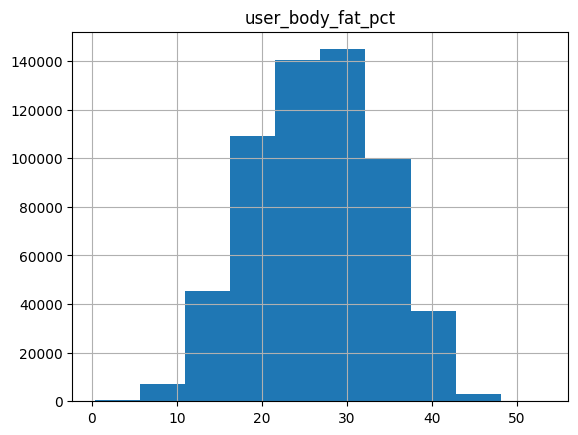

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ["user_bmi", "user_age", "user_body_fat_pct"]

for column in columns:
    df[column].hist()
    plt.title(column)
    plt.show()

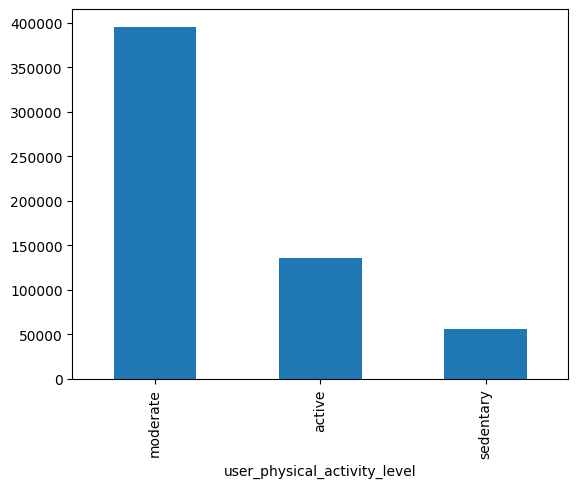

In [210]:
df["user_physical_activity_level"].value_counts().plot(kind="bar")
plt.show()

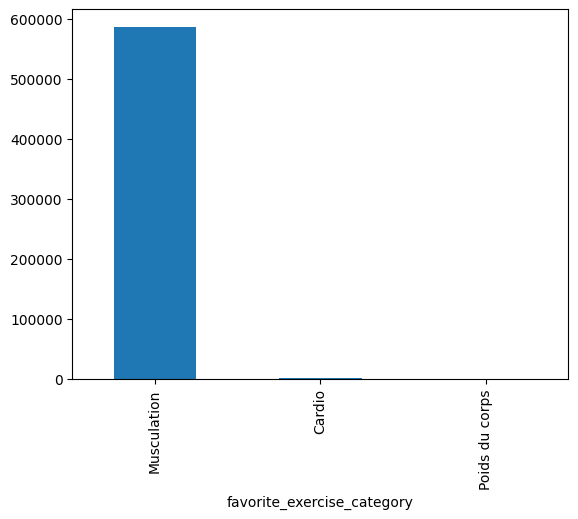

In [211]:
df["favorite_exercise_category"].value_counts().plot(kind="bar")
plt.show()

In [212]:
print("Age range:", df["user_age"].min(), "to", df["user_age"].max())
print("BMI range:", df["user_bmi"].min(), "to", df["user_bmi"].max())
print("Body fat % range:", df["user_body_fat_pct"].min(), "to", df["user_body_fat_pct"].max())

Age range: 18 to 64
BMI range: 8.7 to 38.61
Body fat % range: 0.37 to 53.37


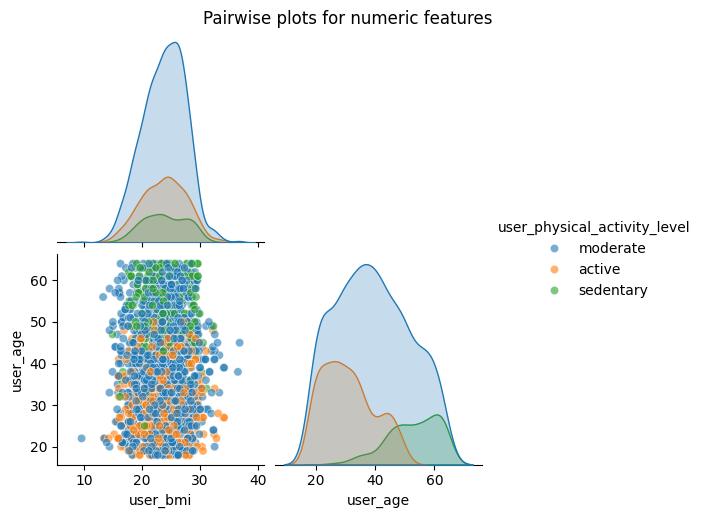

In [213]:
sns.pairplot(
    sample_df,
    vars=["user_bmi", "user_age"],
    hue="user_physical_activity_level",
    palette="tab10",
    corner=True,
    plot_kws={"alpha": 0.6},
)
plt.suptitle("Pairwise plots for numeric features", y=1.02)
plt.show()

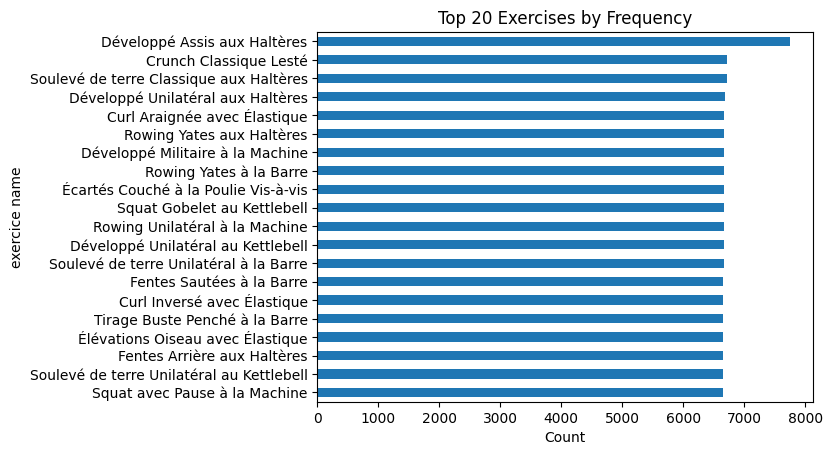

In [214]:
# Exercise frequency and top exercises
exercise_counts = df["exercice name"].value_counts().head(20)
exercise_counts.plot(kind="barh")
plt.title("Top 20 Exercises by Frequency")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

### Nettoyage

remove bad data

convert enum to numerical

In [215]:
# mapping = {
#     "sedentary": 0,
#     "moderate": 1,
#     "active": 2
# }

# df["user_physical_activity_level"] = df["user_physical_activity_level"].map(mapping)

# print(df["user_physical_activity_level"][0])


In [216]:
# mapping = {
#     "force": 0,
#     "souplesse": 1,
#     "cardio": 2,
#     "équilibre" : 3
# }

# df["favorite_exercise_category"] = df["favorite_exercise_category"].map(lambda x: x.lower() if isinstance(x, str) else x).map(mapping)

# print(df["favorite_exercise_category"][0])


In [217]:
df = df[df["user_body_fat_pct"] >= 5]
df = df[df["user_body_fat_pct"] <= 70]

In [218]:
df = df.dropna(subset=['user_bmi', 'user_age', 'user_body_fat_pct', 'exercice name', 'favorite_exercise_category', 'user_physical_activity_level'])

print(len(df))

587182


quick data paranthesis after converting str to int

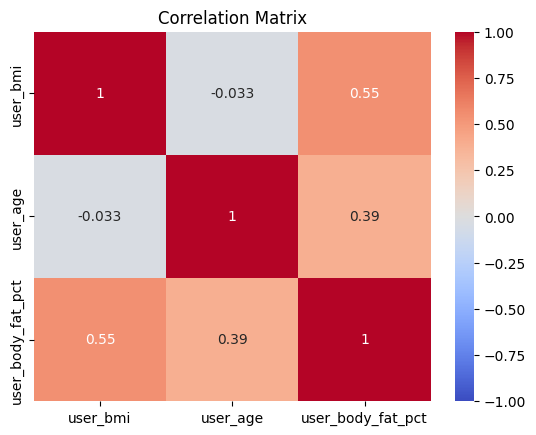

In [219]:
numeric_cols = ["user_bmi", "user_age", "user_body_fat_pct"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [220]:
counts = df["exercice name"].value_counts()

df_filtered = df[
    df["exercice name"].isin(counts[counts >= 20].index)
]
print(len(df_filtered["exercice name"].unique()))
print(len(df_filtered))

205
586993


In [221]:
user_exercises = (
    df_filtered
    .groupby("user_id")["exercice name"]
    .apply(set)
    .reset_index()
)

In [222]:
user_features = df_filtered.groupby("user_id")[[
    'user_physical_activity_level',
    'user_bmi',
    'user_age',
    'user_body_fat_pct',
    'favorite_exercise_category'
]].first().reset_index()

In [223]:
df_user_level = user_features.merge(user_exercises, on="user_id")

print(df_user_level)

                                   user_id user_physical_activity_level  \
0     0000af12-5f62-4fd5-a7b2-78905cc519ce                       active   
1     000fe144-0645-4255-90b0-37a325231c89                     moderate   
2     0017d536-2cda-489b-aca5-ffe713c0e64e                       active   
3     001fce9d-f0a4-4f0f-83ad-5106abdfde8e                     moderate   
4     002d7ec1-c536-4520-a73d-ae995cc60052                    sedentary   
...                                    ...                          ...   
9708  ffe93327-a8b7-4d14-a2f4-f5d1592a6c8e                       active   
9709  ffe988a6-a04d-4529-b9b5-6881494ed687                     moderate   
9710  fff24b2d-326c-420b-90cd-32653abb0ea6                     moderate   
9711  fff5245d-24b9-48a1-9dc1-001798038106                     moderate   
9712  fff8aecf-7c28-4391-9672-ebc8982af687                     moderate   

      user_bmi  user_age  user_body_fat_pct favorite_exercise_category  \
0        22.80        35 

### Prepare Data

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, OneHotEncoder

mlb = MultiLabelBinarizer()

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

FEATURES = ['user_physical_activity_level', 'user_bmi', 'user_age', 'user_body_fat_pct', 'favorite_exercise_category']
X = df_user_level[FEATURES]
y = mlb.fit_transform(df_user_level['exercice name'])

print(len(X))

gkf = GroupKFold(n_splits=2)

groups = df_user_level["user_id"]

train_idx, test_idx = next(gkf.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

categorical_features = [
    'user_physical_activity_level',
    'favorite_exercise_category'
]

numeric_features = [
    'user_bmi',
    'user_age',
    'user_body_fat_pct'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
         categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.fit_transform(X_test)

# X_train, X_test, y_train, y_test, user_ids_train, user_ids_test = train_test_split(
#     X, y, user_ids, test_size=0.5, random_state=42, stratify=y)
# print(f'Train: {len(X_train)} | Test: {len(X_test)}')

9713


## Train Ai

settings

In [235]:
import numpy as np

from sklearn.metrics import make_scorer, top_k_accuracy_score

all_labels = np.unique(y)

def top5_scorer(estimator, X, y_true_sets):
    k = 5
    probs = estimator.predict_proba(X)
    classes = estimator.classes_
    n = len(X)

    hits = 0

    for i in range(n):
        topk_idx = np.argpartition(probs[i], -k)[-k:]
        preds = set(classes[topk_idx])

        if preds.intersection(y_true_sets[i]):
            hits += 1

    return hits / n

def top1_in_set_scorer(estimator, X, y_true_sets):
    y_pred_proba = estimator.predict_proba(X)

    correct = 0

    for i in range(len(X)):
        top1_index = y_pred_proba[i].argmax()
        predicted_exercise = estimator.classes_[top1_index]

        if predicted_exercise in y_true_sets[i]:
            correct += 1

    return correct / len(X)

In [236]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model_logistic_regression = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(
        LogisticRegression(
            solver="saga",
            max_iter=10000,
            class_weight="balanced")
        
    )
)

params = [
    {
        "onevsrestclassifier__estimator__C": [0.01, 0.1, 1],
    },
]

random_search_regression = RandomizedSearchCV(
    model_logistic_regression,
    param_distributions= params,
    n_iter=3,
    cv=gkf,
    scoring=top5_scorer,
    verbose=3,
    random_state=42
)

In [249]:
from sklearn.ensemble import RandomForestClassifier

model_desision_tree = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(
        RandomForestClassifier(
            max_features="sqrt",
            class_weight="balanced",
            n_estimators=600,
            max_depth=30,
            min_samples_leaf=50,
            min_samples_split=100)
    )
)

# params = [
#     {
#         "onevsrestclassifier__estimator__n_estimators": [400, 500, 600],
#         "onevsrestclassifier__estimator__max_depth": [None, 20, 30],
#         "onevsrestclassifier__estimator__min_samples_leaf": [10, 50, 100],
#         "onevsrestclassifier__estimator__min_samples_split": [10, 50, 100, 200]
#     }
# ]

params = [
    {
        "onevsrestclassifier__estimator__n_estimators": [500],
        "onevsrestclassifier__estimator__max_depth": [20],
        "onevsrestclassifier__estimator__min_samples_leaf": [50],
        "onevsrestclassifier__estimator__min_samples_split": [10]
    }
]

random_search_tree = RandomizedSearchCV(
    model_desision_tree,
    param_distributions= params,
    n_iter=1,
    cv=gkf,
    scoring=top5_scorer,
    verbose=3,
    random_state=42
)

train

In [247]:
random_search_regression.fit(X_train_encoded, y_train, groups=groups_train)

best_model_regression = random_search_regression.best_estimator_

Fitting 2 folds for each of 3 candidates, totalling 6 fits


KeyboardInterrupt: 

In [250]:
random_search_tree.fit(X_train_encoded, y_train, groups=groups_train)

best_model_tree = random_search_tree.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits
[CV 1/2] END onevsrestclassifier__estimator__max_depth=20, onevsrestclassifier__estimator__min_samples_leaf=50, onevsrestclassifier__estimator__min_samples_split=10, onevsrestclassifier__estimator__n_estimators=500;, score=0.001 total time= 3.7min
[CV 2/2] END onevsrestclassifier__estimator__max_depth=20, onevsrestclassifier__estimator__min_samples_leaf=50, onevsrestclassifier__estimator__min_samples_split=10, onevsrestclassifier__estimator__n_estimators=500;, score=0.002 total time= 3.8min


Check performance

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

probs_regression = best_model_regression.predict_proba(X_test)
probs_tree = best_model_tree.predict_proba(X_test)

top_k = 5

top_k_accuracy_regression = top_k_accuracy_score(y_true=y_test, y_score=probs_regression, k=top_k)
top_k_accuracy_tree = top_k_accuracy_score(y_true=y_test, y_score=probs_tree, k=top_k)

print(top5_scorer())
print(top_k_accuracy_tree)

best_model = best_model_regression if top_k_accuracy_regression <= top_k_accuracy_tree else best_model_tree


In [ ]:
probs = best_model.predict_proba(X_test)

top_k_accuracy = top_k_accuracy_score(y_true=y_test, y_score=probs_tree, k=top_k)

print(top_k_accuracy)

In [ ]:
from sklearn.metrics import mean_absolute_error

user_ids_test = user_ids_test.to_numpy()

y_pred = best_model.predict(X_test)

true_sets = {
    user_id: set(y_test[user_ids_test == user_id])
    for user_id in np.unique(user_ids_test)
}

one_of_correct = [
    pred in true_sets[user_id]
    for pred, user_id in zip(y_pred, user_ids_test)
]

one_of_accuracy = np.mean(one_of_correct)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "one_of_accuracy": one_of_accuracy,
    "precision": precision_score(y_test, y_pred, average="micro"),
    "f1": f1_score(y_test, y_pred, average="micro"),
    "l1": mean_absolute_error(y_test, y_pred)
}

In [ ]:
print(metrics)

on average where is the right answer

In [ ]:
place = []

sorted_probs =  np.argsort(probs_regression, axis=1)[:, ::-1]

sorted_probs_tree =  np.argsort(probs_tree, axis=1)[:, ::-1]

for sorted_prob in range(len(sorted_probs)):
    i = 1
    while sorted_probs[sorted_prob][i-1] != y_test[sorted_prob]:
        i+=1
    if i > 5:
        place.append(i)

print(np.average(place))

Learning curve

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=4,
    scoring=one_of_user_accuracy,
    train_sizes=[0.3, 0.5, 0.8, 0.9],
    verbose=3
)

In [ ]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Best RandomizedSearchCV Model)")
plt.legend()
plt.show()

Feature importance

In [ ]:
# logreg = best_model.named_steps["logisticregression"]
rf = best_model.named_steps["randomforestclassifier"]

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

# importance = pd.Series(
#     logreg.coef_[0],
#     index=X.columns
# )

importance = importance.sort_values(key=np.abs, ascending=False)

print(importance)

The data has few extreme BMI below 15 above 30 most sedentary user are 40 up so we should check how it behave with those

the general ai is at around 26 and on average the expected "answer" is in whithin the 17 range but the ai is a recomendation it doesn't give a one true answer but a fitting answer 

the learning curve are close so the model seem to be fine with data not in training but the ai accuracy is low but as previously mentioned there isn't realy an answer 

the model could integrade user experiance once we have it

In [ ]:
import os

import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/model.pkl')
joblib.dump(le,  '../models/encoder.pkl')
print('models/model.pkl and models/encoder.pkl created')